# **Internship Task 5: Decision Trees and Random Forests**

**Objective:**

Build a model to predict Loan Approval (Yes/No) using tree-based models.

Decision Tree Classifier (with visualization + depth control)

Random Forest Classifier (for better generalization)

Interpret feature importances

Use cross-validation to evaluate model performance

# **Dataset Feature Description**

| Feature             | Description                                  |
|------------------------|-------------------------------------------------|
| `Gender`               | Male / Female                                   |
| `Married`              | Marital status (Yes / No)                       |
| `Dependents`           | Number of dependents (0, 1, 2, 3+)              |
| `Education`            | Graduate / Not Graduate                         |
| `Self_Employed`        | Employment status (Yes / No)                    |
| `ApplicantIncome`      | Applicant's income                              |
| `CoapplicantIncome`    | Co-applicant's income                           |
| `LoanAmount`           | Loan amount requested (in thousands)            |
| `Loan_Amount_Term`     | Duration of loan repayment (in days/months)     |
| `Credit_History`       | 1 = Good, 0 = Bad or no credit history          |
| `Property_Area`        | Property location: Urban / Semiurban / Rural    |
| `Loan_Status`          | **Target:** Loan approved (Y = 1, N = 0)        |


# **Step 1: Import Libraries & Load Data**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# **Step 2:  Step 2: Load the Dataset**

In [2]:
df = pd.read_csv("/content/Copy of loan - loan.csv")  # Load your actual file here
df.head()


,Loan_ID,Loan_ID.1,Loan_ID.2,Loan_ID.3,Loan_ID.4,Loan_ID.5,Loan_ID.6,Loan_ID.7,Loan_ID.8,Loan_ID.9,Loan_ID.10,Loan_ID.11,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


#**Step 3: Exploratory Data Analysis (EDA)**
Check for missing values

Visualize target distribution

Plot correlations

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Loan_ID      614 non-null    object 
 1   Loan_ID.1    601 non-null    object 
 2   Loan_ID.2    611 non-null    object 
 3   Loan_ID.3    599 non-null    object 
 4   Loan_ID.4    614 non-null    object 
 5   Loan_ID.5    582 non-null    object 
 6   Loan_ID.6    614 non-null    int64  
 7   Loan_ID.7    614 non-null    float64
 8   Loan_ID.8    592 non-null    float64
 9   Loan_ID.9    600 non-null    float64
 10  Loan_ID.10   564 non-null    float64
 11  Loan_ID.11   614 non-null    object 
 12  Loan_Status  614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


<Axes: xlabel='Loan_Status', ylabel='count'>

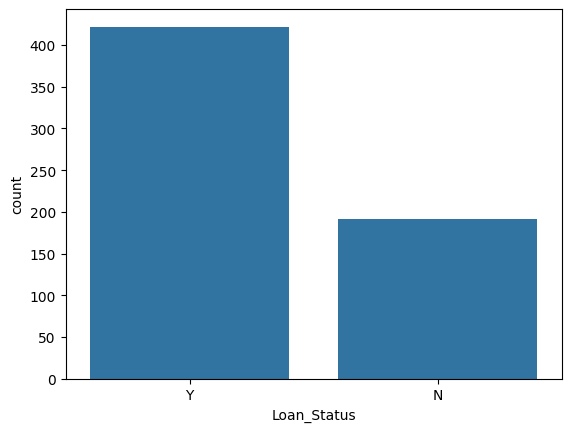

In [3]:
df.info()
df.isnull().sum()
sns.countplot(x='Loan_Status', data=df)




# **Basic structure and insights from the dataset:**

- **Total entries:** 614  
- **Total columns:** 13  
- Some columns like `Loan_ID.1`, `Loan_ID.2`, etc. appear to be duplicates or incorrectly named  
- Several columns contain missing values, especially in `Loan_ID.1`, `Loan_ID.3`, `Loan_ID.10`, etc.  
- **Target variable `Loan_Status` has imbalanced classes:**
  - **Approved (Y):** Approximately 420  
  - **Not Approved (N):** Approximately 190  

This indicates a class imbalance that may affect model performance.  
The bar chart provides a clear visual representation of this distribution.


# **Step 4: Data Preprocessing**

In [4]:
# Replace these with actual column names after inspecting
df.columns = ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
              'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term',
              'Credit_History', 'Property_Area', 'Loan_Status']
from sklearn.preprocessing import LabelEncoder

df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df.fillna(df.mode().iloc[0], inplace=True)

cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,1,0,0,0,0,5849,0.0,120.0,360.0,1.0,2,1
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


# **Data Cleaning & Encoding Summary INSIGHTS**


  Dataset successfully cleaned and encoded  
  Categorical columns encoded using `LabelEncoder`  
  Missing values filled with most frequent (mode) values  
 `Loan_Status` mapped: **Y → 1, N → 0**  
  Target column still contains `NaN` → should be handled (filtered/dropped) before training  
  Now ready for **model building phase**




# **Step 5: Train-Test Split**

In [5]:
X = df.drop(columns=['Loan_ID', 'Loan_Status'])
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# **Step 6: Train a Decision Tree Classifier**

In [6]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Accuracy: 0.7723577235772358
[[18 25]
 [ 3 77]]
              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



# **Decision Tree Classifier - Insights**

- Accuracy achieved: **77.2%**
- Model performs **very well** in identifying loan approvals (class `1`) with **high recall (0.96)** and **F1-score (0.85)**
- Model struggles with loan rejections (class `0`) with **low recall (0.42)**
- Indicates **bias toward predicting approvals**
- To improve: consider **class balancing techniques** or **advanced models** like Random Forest for better generalization


# **Step 7: Visualize the Decision Tree**

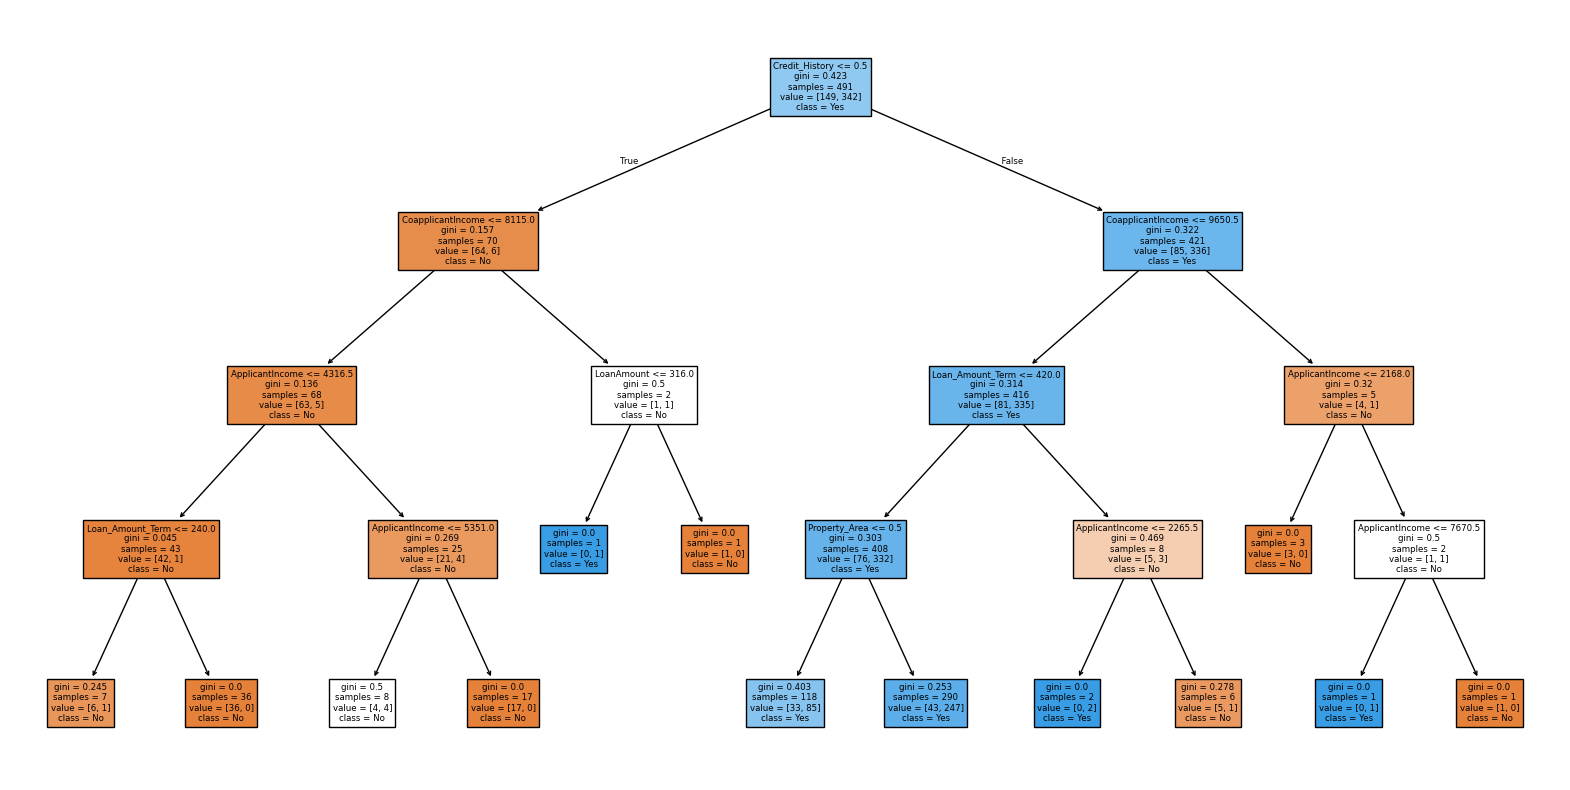

In [7]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No', 'Yes'], filled=True)
plt.show()


# **Decision Tree Visualization - Insight**s

- The root node splits on `Credit_History`, indicating it is the most important feature for predicting loan approval.
- When `Credit_History <= 0.5` (typically poor credit), most predictions are for loan rejection (`class = No`).
- When `Credit_History > 0.5`, features like `CoapplicantIncome`, `Loan_Amount_Term`, and `Property_Area` influence the decision.
- Branches with low Gini index (close to 0) show pure or nearly pure class distributions — high model confidence.
- Applicant financial factors like `ApplicantIncome` and `LoanAmount` are important at deeper levels.
- Tree depth and splits are well-controlled due to `max_depth=4`, helping reduce overfitting while still capturing patterns.


# **Step 8: Random Forest Classifier**

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Accuracy: 0.7642276422764228
[[18 25]
 [ 4 76]]
              precision    recall  f1-score   support

           0       0.82      0.42      0.55        43
           1       0.75      0.95      0.84        80

    accuracy                           0.76       123
   macro avg       0.79      0.68      0.70       123
weighted avg       0.78      0.76      0.74       123



# **Random Forest Classifier - Output Insights**

- **Accuracy:** 76.4% – slightly lower than the Decision Tree (77.2%).
- **Class 1 (Approved Loans):**
  - Precision: 75%
  - Recall: 95% → Model is highly sensitive in detecting approved loans.
  - F1-score: 84% → Balanced performance for class 1.
- **Class 0 (Rejected Loans):**
  - Precision: 82% → High when it predicts "No", it's usually correct.
  - Recall: 42% → Model is not catching many actual "No" cases.
- **Confusion Matrix:**
  - True Positives (Approved correctly): 76
  - True Negatives (Rejected correctly): 18
  - False Positives (Predicted Yes but actually No): 25
  - False Negatives (Predicted No but actually Yes): 4
- **Conclusion:** Model favors approved loans due to class imbalance. Improving class 0 recall is necessary.


# **Step 9:Feature Importance from Random Forest**

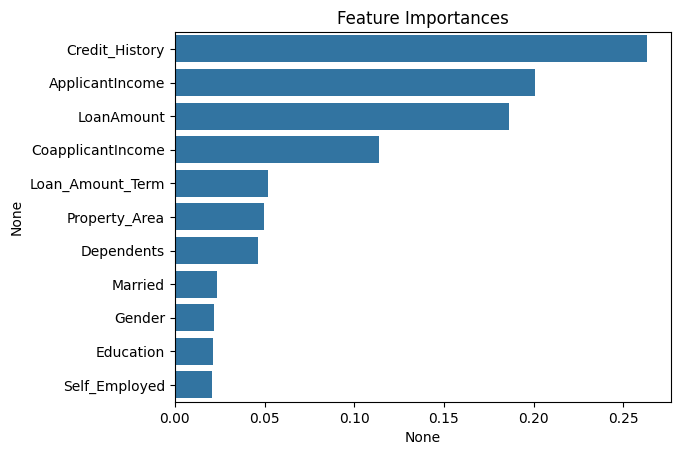

In [11]:
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title("Feature Importances")
plt.show()


# **Feature Importance Insights**

- **Credit_History** is the most important feature, contributing the most to loan approval predictions.
- **ApplicantIncome** and **LoanAmount** are also strong predictors, indicating financial capability is a major factor.
- **CoapplicantIncome** plays a moderate role, especially in cases with joint applications.
- **Loan_Amount_Term**, **Property_Area**, and **Dependents** contribute to a lesser extent.
- Features like **Married**, **Gender**, **Education**, and **Self_Employed** have very low importance.
  - These may not influence approval decisions significantly or may have been captured indirectly by other features.
- Focus for model tuning can be placed on top features to optimize performance and reduce noise.


# **Step 10: Cross-Validation Comparison**

Decision Tree CV Score: 0.7997334399573506
Random Forest CV Score: 0.7882846861255498


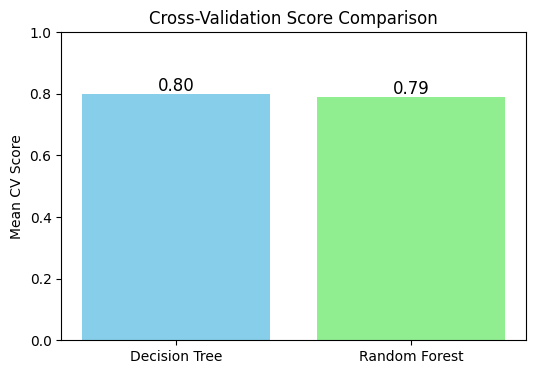

In [13]:
# Cross-validation scores
dt_scores = cross_val_score(dt_model, X, y, cv=5)
rf_scores = cross_val_score(rf_model, X, y, cv=5)

# Print mean scores
print("Decision Tree CV Score:", dt_scores.mean())
print("Random Forest CV Score:", rf_scores.mean())

# Plot the comparison
models = ['Decision Tree', 'Random Forest']
mean_scores = [dt_scores.mean(), rf_scores.mean()]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, mean_scores, color=['skyblue', 'lightgreen'])
plt.title('Cross-Validation Score Comparison')
plt.ylabel('Mean CV Score')
plt.ylim(0, 1)

# Add values on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.2f}', ha='center', fontsize=12)

plt.show()


# **Cross-Validation Score Comparison insights**

- **Cross-validation** is used to check how well our model performs on different parts of the dataset.
- It helps us make sure the model is not just doing well on one test set but performs consistently overall.

#### Average Accuracy Scores from 5-Fold Cross-Validation:
- **Decision Tree Average Score:** 0.7997 (≈ 80%)
- **Random Forest Average Score:** 0.7883 (≈ 79%)

#### Insight:
- The **Decision Tree** model performed slightly better than the **Random Forest** model in cross-validation.
- This means the Decision Tree gave more consistent results across multiple parts of the dataset.
- Even though Random Forest is generally more powerful, in this case, the simpler Decision Tree worked just as well or even a bit better.

✅ **Conclusion:** The Decision Tree is currently the better model for this loan approval prediction task based on average cross-validation accuracy.


# **Final Analysis Of Whole Task**

**Objective:**  
Predict loan approval status using applicant data.

**Models Used:**  
- Decision Tree Classifier  
- Random Forest Classifier

**Performance Summary:**  
- Decision Tree Test Accuracy: ~77%  
- Random Forest Test Accuracy: ~76%  
- Decision Tree Cross-Validation Score: ~80%  
- Random Forest Cross-Validation Score: ~78%

**Key Insights:**  
- Decision Tree performed slightly better overall.  
- Credit History, Applicant Income, and Loan Amount were major influencing features.  
- The models can help automate and improve consistency in loan approval decisions.

**Conclusion:**  
Decision Tree is a strong, interpretable model for this task and can support decision-making effectively.
